<a href="https://www.kaggle.com/code/fatihsoyalp/netflix-fees-and-library-size?scriptVersionId=92602837" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-subscription-price-in-different-countries/Netflix subscription fee Dec-2021.csv
/kaggle/input/netflix-subscription-price-in-different-countries/netflix price in different countries.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../input/netflix-subscription-price-in-different-countries/Netflix subscription fee Dec-2021.csv')

In [4]:
df.head()

,Country_code,Country,Total Library Size,No. of TV Shows,No. of Movies,Cost Per Month - Basic ($),Cost Per Month - Standard ($),Cost Per Month - Premium ($)
0,ar,Argentina,4760,3154,1606,3.74,6.30,9.26
1,au,Australia,6114,4050,2064,7.84,12.12,16.39
2,at,Austria,5640,3779,1861,9.03,14.67,20.32
3,be,Belgium,4990,3374,1616,10.16,15.24,20.32
4,bo,Bolivia,4991,3155,1836,7.99,10.99,13.99


In [5]:
df.shape

(65, 8)

In [6]:
df.describe()

,Total Library Size,No. of TV Shows,No. of Movies,Cost Per Month - Basic ($),Cost Per Month - Standard ($),Cost Per Month - Premium ($)
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,5314.415385,3518.953846,1795.461538,8.368462,11.990000,15.612923
std,980.322633,723.010556,327.279748,1.937819,2.863979,4.040672
min,2274.000000,1675.000000,373.000000,1.970000,3.000000,4.020000
25%,4948.000000,3154.000000,1628.000000,7.990000,10.710000,13.540000
50%,5195.000000,3512.000000,1841.000000,8.990000,11.490000,14.450000
75%,5952.000000,3832.000000,1980.000000,9.030000,13.540000,18.060000
max,7325.000000,5234.000000,2387.000000,12.880000,20.460000,26.960000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country_code                   65 non-null     object 
 1   Country                        65 non-null     object 
 2   Total Library Size             65 non-null     int64  
 3   No. of TV Shows                65 non-null     int64  
 4   No. of Movies                  65 non-null     int64  
 5   Cost Per Month - Basic ($)     65 non-null     float64
 6   Cost Per Month - Standard ($)  65 non-null     float64
 7   Cost Per Month - Premium ($)   65 non-null     float64
dtypes: float64(3), int64(3), object(2)
memory usage: 4.2+ KB


In [8]:
df.groupby('Country').sum()

,Total Library Size,No. of TV Shows,No. of Movies,Cost Per Month - Basic ($),Cost Per Month - Standard ($),Cost Per Month - Premium ($)
Country,,,,,,
Argentina,4760,3154,1606,3.74,6.30,9.26
Australia,6114,4050,2064,7.84,12.12,16.39
Austria,5640,3779,1861,9.03,14.67,20.32
Belgium,4990,3374,1616,10.16,15.24,20.32
Bolivia,4991,3155,1836,7.99,10.99,13.99
...,...,...,...,...,...,...
Ukraine,5336,3261,2075,5.64,8.46,11.29
United Kingdom,6643,4551,2092,7.91,13.20,18.48
United States,5818,3826,1992,8.99,13.99,17.99


In [9]:
len(df['Country'].unique())

65

In [10]:
df[df['Cost Per Month - Basic ($)']==df['Cost Per Month - Basic ($)'].max()][['Country','Cost Per Month - Basic ($)']]

,Country,Cost Per Month - Basic ($)
33,Liechtenstein,12.88
56,Switzerland,12.88


In [11]:
df[df['Cost Per Month - Standard ($)']==df['Cost Per Month - Standard ($)'].max()][['Country','Cost Per Month - Standard ($)']]

,Country,Cost Per Month - Standard ($)
33,Liechtenstein,20.46
56,Switzerland,20.46


In [12]:
df[df['Cost Per Month - Premium ($)']==df['Cost Per Month - Premium ($)'].max()][['Country','Cost Per Month - Premium ($)']]

,Country,Cost Per Month - Premium ($)
33,Liechtenstein,26.96
56,Switzerland,26.96


In [13]:
df[df['Cost Per Month - Basic ($)']==df['Cost Per Month - Basic ($)'].min()][['Country','Cost Per Month - Basic ($)']]

,Country,Cost Per Month - Basic ($)
59,Turkey,1.97


In [14]:
df[df['Cost Per Month - Standard ($)']==df['Cost Per Month - Standard ($)'].min()][['Country','Cost Per Month - Standard ($)']]

,Country,Cost Per Month - Standard ($)
59,Turkey,3.0


In [15]:
df[df['Cost Per Month - Premium ($)']==df['Cost Per Month - Premium ($)'].min()][['Country','Cost Per Month - Premium ($)']]

,Country,Cost Per Month - Premium ($)
59,Turkey,4.02


In [16]:
df.loc[[59,33,56 ],['Country','Total Library Size']]

,Country,Total Library Size
59,Turkey,4639
33,Liechtenstein,3048
56,Switzerland,5506


In [17]:
df[df['Total Library Size']==df['Total Library Size'].max()][['Country','Total Library Size']]

,Country,Total Library Size
12,Czechia,7325


In [18]:
df[df['Total Library Size']==df['Total Library Size'].min()][['Country','Total Library Size']]

,Country,Total Library Size
11,Croatia,2274


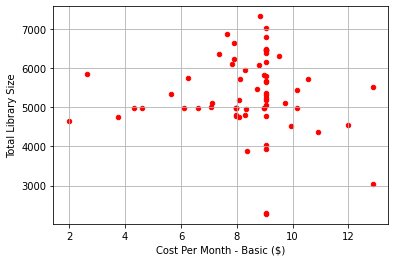

In [19]:
df.plot(x = 'Cost Per Month - Basic ($)',y = 'Total Library Size',kind='scatter',color='red')
plt.grid()
plt.show()

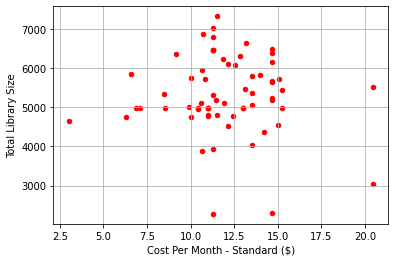

In [20]:
df.plot(x = 'Cost Per Month - Standard ($)',y = 'Total Library Size',kind='scatter',color='red')
plt.grid()
plt.show()

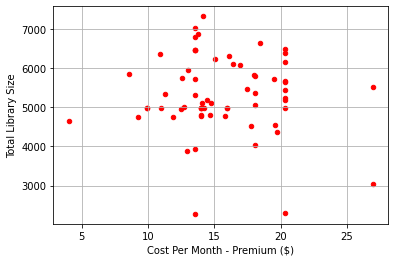

In [21]:
df.plot(x = 'Cost Per Month - Premium ($)',y = 'Total Library Size',kind='scatter',color='red')
plt.grid()
plt.show()

<Figure size 2400x1200 with 0 Axes>

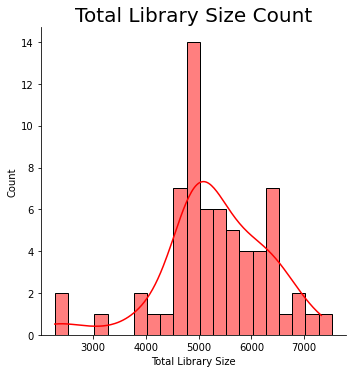

In [22]:
plt.figure(figsize=(12,6),dpi=200)
sns.displot(data=df,x='Total Library Size',kde=True,binwidth=250,color='red')
plt.title('Total Library Size Count', fontsize=20)
plt.show()

<Figure size 2400x1200 with 0 Axes>

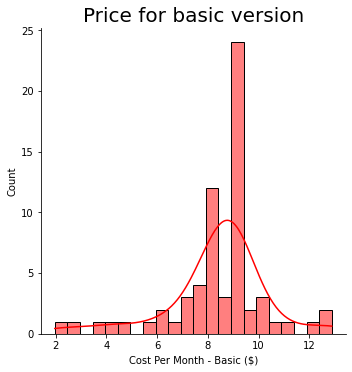

In [23]:
plt.figure(figsize=(12,6),dpi=200)
sns.displot(data=df,x='Cost Per Month - Basic ($)',kde=True,color='red')
plt.title('Price for basic version', fontsize=20)
plt.show()

<Figure size 2400x1200 with 0 Axes>

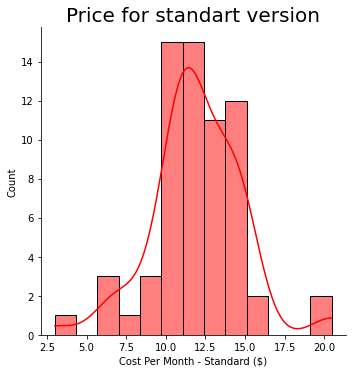

In [24]:
plt.figure(figsize=(12,6),dpi=200)
sns.displot(data=df,x='Cost Per Month - Standard ($)',kde=True,color='red')
plt.title('Price for standart version', fontsize=20)
plt.show()

<Figure size 2400x1200 with 0 Axes>

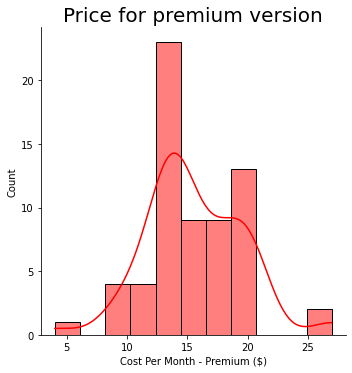

In [25]:
plt.figure(figsize=(12,6),dpi=200)
sns.displot(data=df,x='Cost Per Month - Premium ($)',kde=True,color='red')
plt.title('Price for premium version', fontsize=20)
plt.show()

# *THE RESULT*
*On our this work we have worked on Netflix fees and the size of libraries in 65 different countries;
As we got from our datas people who live in Turkey pays lowest fees for Basic, Standart and Premium versions on global. People who lives in Liechtenstein and Switzerland pays the highest fees which is equal to 12,88 for basic version which is more than Turkey's premium version. While people in Liechtenstein paying more than who live in Turkey, Netflix in Turkey has larger library than Liechtenstein. Netflix in Czechia has largest and in Croatia has smallest library globally.*